In [10]:
# Configure path.
import sys; import os
sys.path.append(os.path.abspath('..'))

# Standard libraries.
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import importlib

# Functions
import python.forces as forces
import python.integrators as integrators
import python.random_matrix as random_matrix 
import python.simulate as simulate
import python.densities as densities

importlib.reload(forces); importlib.reload(integrators); importlib.reload(random_matrix)
importlib.reload(simulate); importlib.reload(densities);

---

Running for 100 steps.


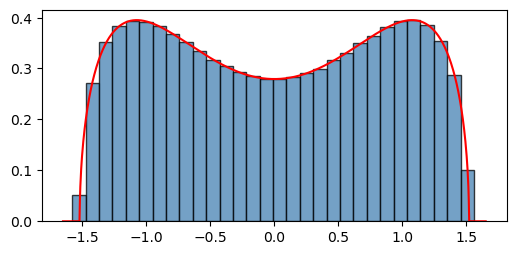

In [17]:
N = 70; beta = 2.0; T = 10.0; M = 2000;
dt = 0.1; total_steps = int(T/dt);
potential_name = "quartic"
print(f"Running for {total_steps} steps.")

init = random_matrix.init_gue_eigenvalues(M, N)
noise_scale = np.sqrt(2.0*dt/(beta*N))

implicit_pipe = simulate.make_implicit_pipeline(dt, noise_scale, beta, potential_name)
traj = simulate.simulate_dbm(init, total_steps, implicit_pipe)
particles = simulate.collect_snapshots(traj, total_steps)

# Quick plotter.
density_range, limiting_density = densities.get_density(potential_name)

fig, ax = plt.subplots(figsize = (6, 2.75))
ax.hist(particles, bins = 30, density = True, color = "steelblue", edgecolor = "black", alpha = 0.75)
ax.plot(density_range, limiting_density, color = "red", lw = 1.5)

plt.show()